[](url) 

**Importing Libraries:**

General Libraries:
re , time , pickle , numpy , pandas

Libraries for Ploting:
matplotlib , seaborn 

Libraries for Word Cloud Visualization:
wordcloud , PIL

Natural Language Processing Libraries:
nltk

Machine Learning Models Libraries
LinearSVC , BernoulliNB , LogisticRegression from 

Model Training and Evaluation Libraries:
train_test_split , TfidfVectorizer , confusion_matrix , classification_report from sklearn


In [0]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
import re
import time
import pickle
import numpy as np
import pandas as pd
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
from wordcloud import WordCloud
import PIL
import pip
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

/databricks/python/lib/python3.9/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**Loading and Preparing the Dataset**

In [0]:
# -----------------------------------------------------------------Define the column names--------------------------------------------------------------------

DATASET_COLUMNS = ["sentiment", "ids", "date", "flag", "user", "text"]

# -------------------------------------------Load the CSV file with Spark and convert it to a Pandas DataFrame------------------------------------------------

dataset = spark.read.format('csv') \
    .options(header='false', delimiter=',', inferSchema='true') \
    .load('/FileStore/tables/training_1600000_processed_noemoticon.csv') \
    .toPandas()

# -----------------------------------------------------------------Assign the column names -------------------------------------------------------------------

dataset.columns = DATASET_COLUMNS

#---------------------------------------------------- Showing the first few rows of the Pandas DataFrame------------------------------------------------------

dataset.head()

,sentiment,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


**Data Cleaning and Preparation**

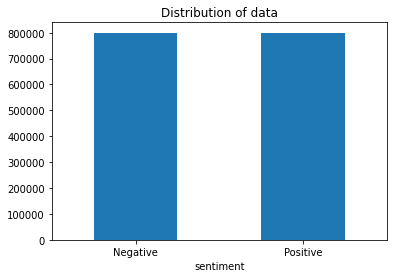

In [0]:
# -------------------------------------------------------------Removing the unnecessary columns-------------------------------------------------------------

dataset = dataset[['sentiment','text']]

# -------------------------------------------------------Replacing the values for better understanding------------------------------------------------------

dataset['sentiment'] = dataset['sentiment'].replace(4,1)

# -----------------------------------------------------------Plotting the distribution for dataset-----------------------------------------------------------

ax = dataset.groupby('sentiment').count().plot(kind='bar', title='Distribution of data', legend=False)

ax.set_xticklabels(['Negative','Positive'], rotation=0)

# ------------------------------------------------------------------Storing data in lists--------------------------------------------------------------------

text, sentiment = list(dataset['text']), list(dataset['sentiment'])

**Defining Emoji Dictionary & Stopwords List**

In [0]:
# --------------------------------------------------------Assigining a word for describing each emoji--------------------------------------------------------

emojis = {':)': 'smile', ':-)': 'smile', ';d': 'wink', ':-E': 'vampire', ':(': 'sad',':-(': 'sad', ':-<': 'sad', ':P': 'raspberry', ':O': 'surprised',':-@': 'shocked', ':@': 'shocked',':-$': 'confused', ':\\': 'annoyed',':#': 'mute', ':X': 'mute', ':^)': 'smile', ':-&': 'confused', '$_$': 'greedy','@@': 'eyeroll', ':-!': 'confused', ':-D': 'smile', ':-0': 'yell', 'O.o': 'confused','<(-_-)>': 'robot', 'd[-_-]b': 'dj', ":'-)": 'sadsmile', ';)': 'wink',';-)': 'wink', 'O:-)': 'angel','O*-)': 'angel','(:-D': 'gossip', '=^.^=': 'cat'}

# ------------------------------------------------------------------Stopwords in english------------------------------------------------------------------

stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an','and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do','does', 'doing', 'down', 'during', 'each','few', 'for', 'from','further', 'had', 'has', 'have', 'having', 'he', 'her', 'here','hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma','me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once','only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're','s', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such','t', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them','themselves', 'then', 'there', 'these', 'they', 'this', 'those','through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was','we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom','why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre","youve", 'your', 'yours', 'yourself', 'yourselves']

**Defining Text Preprocessing Function**

This function will do

1.Initialize the base of each word

2.Define Regex Pattern.

3.Converts text to lowercase and replaces URLs with "URL" to remove unnecessary web links.

4.Replace Emojis with Their Meanings (based on the above dictionary)

5.Replaces @username with "USER" to remove personal identifiers

6.Lemmatization and Stopword Removal (based on the aforementioned list)

In [0]:
def preprocess(textdata):
    processedText = []
    
    # Create Lemmatizer and Stemmer
    wordLemm = WordNetLemmatizer()
    
    # Defining regex patterns
    urlPattern        = r"((http://)[^ ]*|(https://)[^ ]*|( www\.)[^ ]*)"
    userPattern       = '@[^\s]+'
    alphaPattern      = "[^a-zA-Z0-9]"
    sequencePattern   = r"(.)\1\1+"
    seqReplacePattern = r"\1\1"
    
    for tweet in textdata:
        tweet = tweet.lower()
        
        # Replace all URls with 'URL'
        tweet = re.sub(urlPattern,' URL',tweet)
        # Replace all emojis
        for emoji in emojis.keys():
            tweet = tweet.replace(emoji, "EMOJI" + emojis[emoji])        
        # Replace @USERNAME to 'USER'
        tweet = re.sub(userPattern,' USER', tweet)        
        # Replace all non alphabets
        tweet = re.sub(alphaPattern, " ", tweet)
        # Replace 3 or more consecutive letters by 2 letter
        tweet = re.sub(sequencePattern, seqReplacePattern, tweet)

        tweetwords = ''
        for word in tweet.split():
            # Checking if the word is a stopword
            #if word not in stopwordlist:
            if len(word)>1:
                # Lemmatizing the word
                word = wordLemm.lemmatize(word)
                tweetwords += (word+' ')
            
        processedText.append(tweetwords)
        
    return processedText

In [0]:
t = time.time()
processedtext = preprocess(text)
print(f'Text Preprocessing complete.')
print(f'Time Taken: {round(time.time()-t)} seconds')

Text Preprocessing complete.
Time Taken: 231 seconds


Out[7]: <matplotlib.image.AxesImage at 0x7f2d8a7ec7c0>

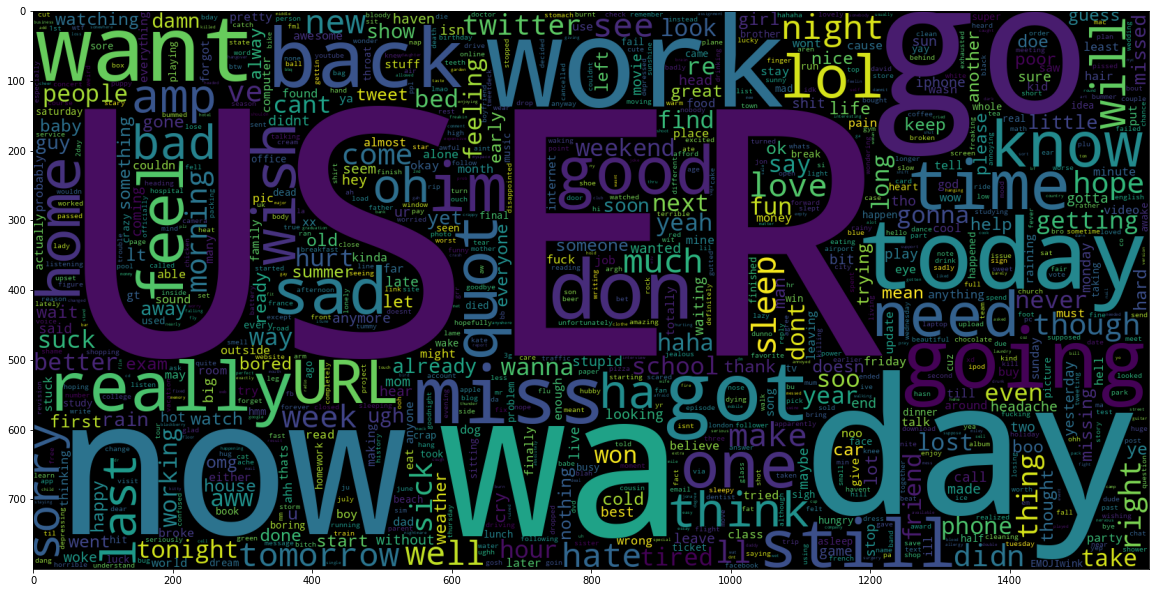

In [0]:
#------------------------------------------------------------------------Negative------------------------------------------------------------------------

data_neg = processedtext[:800000]
plt.figure(figsize = (20,20))
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
               collocations=False).generate(" ".join(data_neg))
plt.imshow(wc)

Out[8]: <matplotlib.image.AxesImage at 0x7f2d848be850>

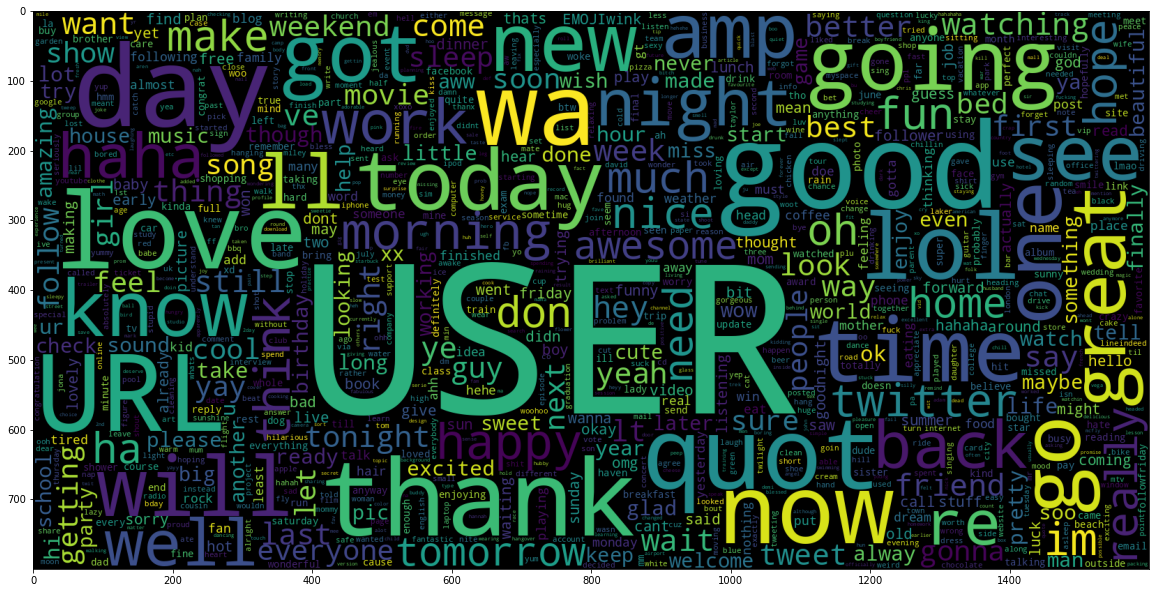

In [0]:
#------------------------------------------------------------------------Positive------------------------------------------------------------------------

data_pos = processedtext[800000:]
wc = WordCloud(max_words = 1000 , width = 1600 , height = 800,
              collocations=False).generate(" ".join(data_pos))
plt.figure(figsize = (20,20))
plt.imshow(wc)

**Splitting Data into Training and Testing Sets** & **Initializing and Fitting a TF-IDF Vectorizer**

In [0]:
X_train, X_test, y_train, y_test = train_test_split(processedtext, sentiment,
                                                    test_size = 0.05, random_state = 0)
print(f'Data Split done.')
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features=500000)
vectoriser.fit(X_train)
print(f'Vectoriser fitted.')
print('No. of feature_words: ', len(vectoriser.get_feature_names_out()))
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
X_train = vectoriser.transform(X_train)
X_test  = vectoriser.transform(X_test)
print(f'Data Transformed.')

Data Split done.
Vectoriser fitted.
No. of feature_words:  500000
Data Transformed.


**Defining Model Evaluation Function**

This function will:

1.Predicts sentiments on test data

2.Displays classification metrics (Precision, Recall, F1-score, Accuracy)

3.Creates a confusion matrix to analyze errors

4.Visualizes results using Seaborn heatmap

In [0]:

def model_Evaluate(model): 

    # Predict values for Test dataset
    y_pred = model.predict(X_test)
     # Print the evaluation metrics for the dataset
    print(classification_report(y_test, y_pred))
    cf_matrix = confusion_matrix(y_test, y_pred) 

    categories  = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos'] 
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)


    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)
   
    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

**Model Evaluation**

1) Bernoulli Naïve Bayes (BNB)


              precision    recall  f1-score   support

           0       0.81      0.79      0.80     39989
           1       0.80      0.81      0.80     40011

    accuracy                           0.80     80000
   macro avg       0.80      0.80      0.80     80000
weighted avg       0.80      0.80      0.80     80000



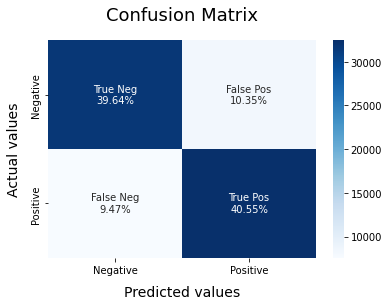

In [0]:
BNBmodel = BernoulliNB(alpha = 2)
BNBmodel.fit(X_train, y_train)
model_Evaluate(BNBmodel)

**Model Evaluation**

2) Support Vector Classifier (SVC)

              precision    recall  f1-score   support

           0       0.82      0.81      0.82     39989
           1       0.81      0.83      0.82     40011

    accuracy                           0.82     80000
   macro avg       0.82      0.82      0.82     80000
weighted avg       0.82      0.82      0.82     80000



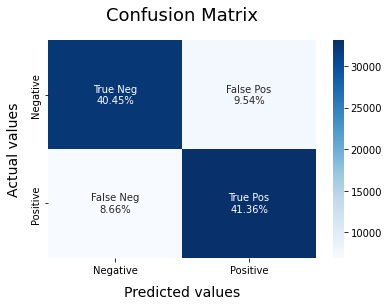

In [0]:
SVCmodel = LinearSVC()
SVCmodel.fit(X_train, y_train)
model_Evaluate(SVCmodel)

**Model Evaluation**

3) Logistic Regression (LR)

              precision    recall  f1-score   support

           0       0.83      0.82      0.83     39989
           1       0.82      0.84      0.83     40011

    accuracy                           0.83     80000
   macro avg       0.83      0.83      0.83     80000
weighted avg       0.83      0.83      0.83     80000



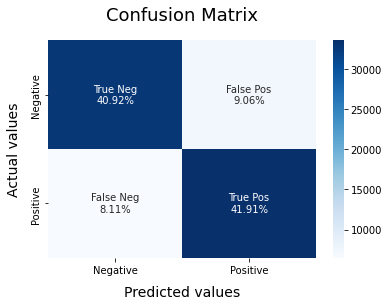

In [0]:
LRmodel = LogisticRegression(C = 2, max_iter = 1000, n_jobs=-1)
LRmodel.fit(X_train, y_train)
model_Evaluate(LRmodel)

In [0]:
file = open('vectoriser-ngram-(1,2).pickle','wb')
pickle.dump(vectoriser, file) 
file.close()

file = open('Sentiment-LR.pickle','wb')
pickle.dump(LRmodel, file)
file.close()

file = open('Sentiment-BNB.pickle','wb')
pickle.dump(BNBmodel, file)
file.close()

**Model Saving, Loading, and Predictio**

In [0]:
def load_models():

    # Load the vectoriser
    file = open('..path/vectoriser-ngram-(1,2).pickle', 'rb')
    vectoriser = pickle.load(file)
    file.close()
    # Load the LR Model
    file = open('..path/Sentiment-LRv1.pickle', 'rb')
    LRmodel = pickle.load(file)
    file.close()

    return vectoriser, LRmodel

def predict(vectoriser, model, text):
    # Predict the sentiment
    textdata = vectoriser.transform(preprocess(text))
    sentiment = model.predict(textdata)

     # Make a list of text with sentiment
    data = []
    for text, pred in zip(text, sentiment):
        data.append((text,pred))

         # Convert the list into a Pandas DataFrame
    df = pd.DataFrame(data, columns = ['text','sentiment'])
    df = df.replace([0,1], ["Negative","Positive"])
    return df

if __name__=="__main__":
    # Loading the models
    #vectoriser, LRmodel = load_models()
    
    # Text to classify should be in a list
    
    text = ["I am a good girl",
            "That house is old",
            "I Hate mornings",
            "I like sunrise"]
    
    df = predict(vectoriser, LRmodel, text)
    print(df.head())

                text sentiment
0   I am a good girl  Positive
1  That house is old  Negative
2    I Hate mornings  Negative
3     I like sunrise  Positive
